# Case Study 2: Looking into Power Swing Damping Capabilities

In [1]:
%load_ext autoreload
%autoreload 2

## Imports and Definitions

In [2]:
import os
import sys
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm

In [3]:
from development_files.examples.ibb_transformer.ibb_trans_model import load as ibb
from development_files.examples.simple_load.simple_load_mod import load as simple_load

from diffpssi import PowerSystemSimulation as Pss
from diffpssi.power_sim_lib import Recorder

# from src.diffpssi.stability_lib import VoltageStability
from diffpssi.stability_lib.voltage import NoseCurve
from diffpssi.stability_lib.voltage import ViolationIntegral, CrtiticalTimes

from diffpssi.tools import set_matplot_settings

set_matplot_settings(
    font_family="Times New Roman",
    font_size=10,
)

In [4]:
save = os.path.join(os.getcwd(), "plots_paper/")
if not os.path.exists(save):
    os.makedirs(save)

parallel_sims = 1

In [5]:
def load_dependency(t, start_time=1, initial_p=400):
    """Generating a time dependency for the load in the simulation.

    :param t: Simulation timestep.
    :type t: _type_
    """
    p = initial_p + t * 80
    return p

## Simulation Set Up

First, the transformer parameters and the scenario is described and set.

In [6]:
param_dict_fsm = {
    "t_m": 0.02,
    "t_k": 5,
    "db": 0.025,
    "delta_m": 2,
    "delta_k": 0.02,
    "m_max": 4,
    "m_min": -4,
    "k_max": 10,
    "k_min": -10,
    "v_ref": 1,
    "gamma_max": 8,
    "pt_1": 0.01,
}

param_dict_oltc = {
    "t_1": 5,
    "db": 0.05,
    "delta_m": 0.02,
    "m_max": 1.1,  # 1.35,
    "m_min": 0.9,  # 0.65,
    "v_ref": 1,
}

sim_time = 120
fault_end = 1.06
xlims = (0, 8)
ylims_v = (-0.1, 1.2)
ylims_p = (-0.1, 1.5)
ylims_speed = (-0.01, 0.01)


def set_scenario(sim, rec):
    sim.add_sc_event(1, fault_end, "B1")
    # sim.add_param_event(1, sim.busses[1].models[0], 'p_soll_mw', 1100)

    if hasattr(sim.trafos[0], "oltc"):
        sim.trafos[0].oltc.dir = 1

    sim.set_record_function(rec.record_fun)
    return

In [7]:
def record_dict_case2_simple(simulation, call=False):
    record_dict = {
        "Bus 0: Voltage Magnitude": simulation.busses[0].get_value("voltage_mag"),
        "Bus 1: Voltage Magnitude": simulation.busses[1].get_value("voltage_mag"),
        "Bus 2: Voltage Magnitude": simulation.busses[2].get_value("voltage_mag"),
        r"Machine Speed": simulation.busses[2].models[0].omega,
        r"Machine Angle": simulation.busses[2].models[0].delta,
        "Machine P_e": simulation.busses[2].models[0].p_e,
        "Machine P_m": simulation.busses[2].models[0].p_m,
    }
    if call:
        return record_dict.values()
    else:
        return record_dict


def record_dict_case2_oltc(simulation, call=False):
    record_dict = {
        "Bus 0: Voltage Magnitude": simulation.busses[0].get_value("voltage_mag"),
        "Bus 1: Voltage Magnitude": simulation.busses[1].get_value("voltage_mag"),
        "Bus 2: Voltage Magnitude": simulation.busses[2].get_value("voltage_mag"),
        "Machine Speed": simulation.busses[2].models[0].omega,
        "Machine Angle": simulation.busses[2].models[0].delta,
        "Machine P_e": simulation.busses[2].models[0].p_e,
        "Machine P_m": simulation.busses[2].models[0].p_m,
        # OLTC realted
        "Transformer Ratio": simulation.trafos[0].oltc.u_l,
        "Voltage Difference": simulation.trafos[0].oltc.v_diff,
    }
    if call:
        return record_dict.values()
    else:
        return record_dict

## Simple Uncontrolled Transformer

In [8]:
sim_simple = Pss(
    parallel_sims=parallel_sims,
    sim_time=sim_time,
    time_step=0.005,
    solver="heun",
    grid_data=ibb(
        measure_side="lv",
        trans_type="simple",
        trans_control="oltc",
        param_dict_oltc=param_dict_oltc,
        controllers=False,
    ),
)

rec_simple = Recorder(sim=sim_simple, recorder_dict=record_dict_case2_simple)
record_list_simple = rec_simple.record_list()

set_scenario(sim_simple, rec_simple)

t, recorder_simple = sim_simple.run()

res_simple = pd.DataFrame(recorder_simple[0, :, :], columns=record_list_simple)
res_simple["t"] = t
res_simple.set_index("t", inplace=True)

res_simple.head()

Load flow finished in 3 iterations with error 2.65e-09 in 0.0330 seconds


100%|██████████| 24000/24000 [00:17<00:00, 1334.22it/s]

Dynamic simulation finished in 18.01 seconds


,Bus 0: Voltage Magnitude,Bus 1: Voltage Magnitude,Bus 2: Voltage Magnitude,Machine Speed,Machine Angle,Machine P_e,Machine P_m
t,,,,,,,
0.000,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,1.110223e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j
0.005,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,2.101494e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j
0.010,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,2.973812e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j
0.015,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,3.806479e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j
0.020,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,4.599495e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j


### Inspection of the Results

/Users/maxikoehler/Documents/GitHub/diffpssi_b/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/maxikoehler/Documents/GitHub/diffpssi_b/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


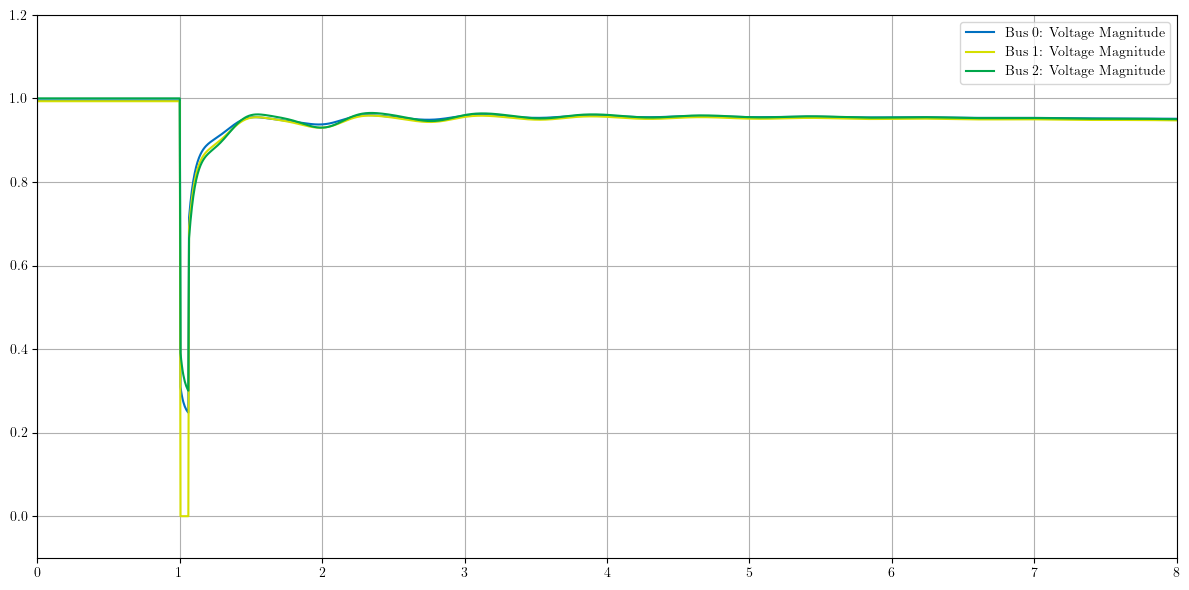

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    res_simple.index.values,
    res_simple["Bus 0: Voltage Magnitude"],
    label="Bus 0: Voltage Magnitude",
)
plt.plot(
    res_simple.index.values,
    res_simple["Bus 1: Voltage Magnitude"],
    label="Bus 1: Voltage Magnitude",
)
plt.plot(
    res_simple.index.values,
    res_simple["Bus 2: Voltage Magnitude"],
    label="Bus 2: Voltage Magnitude",
)

plt.grid()
plt.legend()

plt.xlim(xlims)
plt.ylim(ylims_v)

plt.show()

/Users/maxikoehler/Documents/GitHub/diffpssi_b/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/maxikoehler/Documents/GitHub/diffpssi_b/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


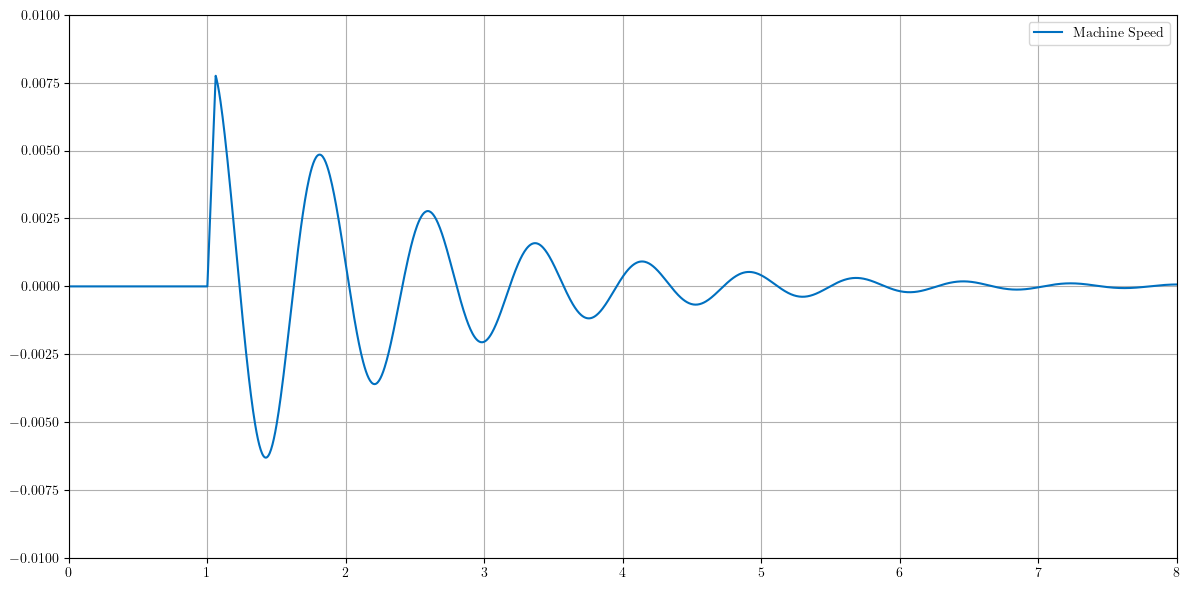

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(res_simple.index.values, res_simple.iloc[:, 3], label="Machine Speed")
# plt.plot(res_simple.index.values, res_simple.iloc[:, 4], label='Machine Angle')

plt.xlim(xlims)
plt.ylim(ylims_speed)
plt.grid()
plt.legend()

plt.show()

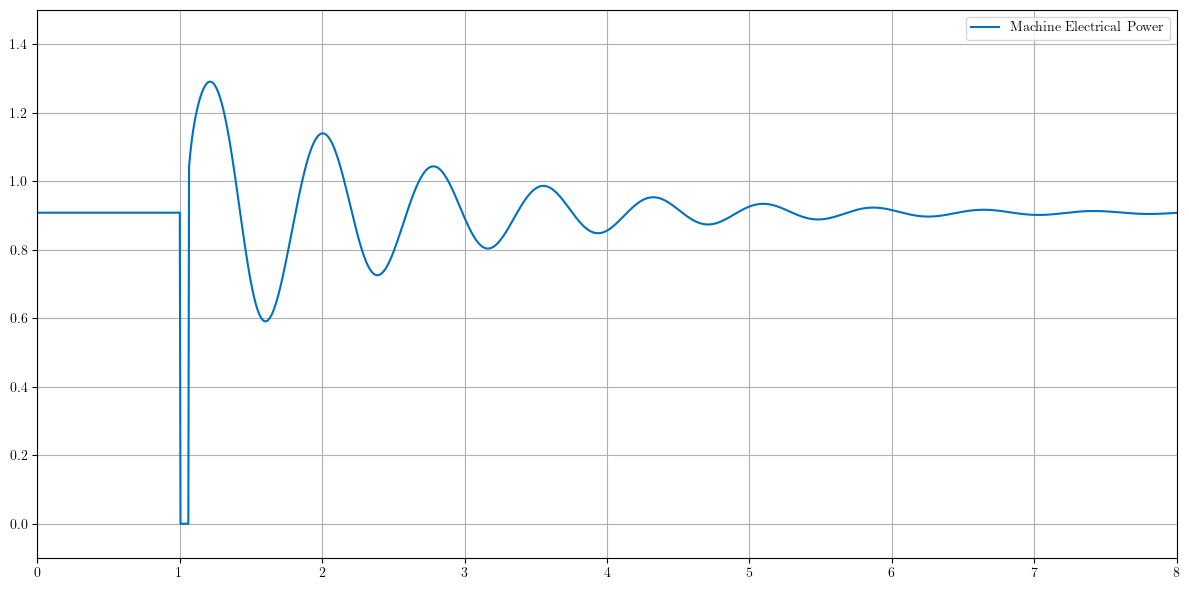

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    res_simple.index.values, res_simple["Machine P_e"], label="Machine Electrical Power"
)
# plt.plot(res_simple.index.values, res_simple['Machine P_m'], label='Machine Mechanical Power')

plt.xlim(xlims)
plt.ylim(ylims_p)
plt.grid()
plt.legend()

plt.show()

## OLTC Controlled

In [12]:
sim_oltc = Pss(
    parallel_sims=parallel_sims,
    sim_time=sim_time,
    time_step=0.005,
    solver="heun",
    grid_data=ibb(
        measure_side="lv",
        trans_type="oltc",
        trans_control="oltc",
        param_dict_oltc=param_dict_oltc,
        controllers=False,
    ),
)

rec_oltc = Recorder(sim=sim_oltc, recorder_dict=record_dict_case2_oltc)
record_list_oltc = rec_oltc.record_list()

set_scenario(sim_oltc, rec_oltc)

t, recorder_oltc = sim_oltc.run()

res_oltc = pd.DataFrame(recorder_oltc[0, :, :], columns=record_list_oltc)
res_oltc["t"] = t
res_oltc.set_index("t", inplace=True)

res_oltc.head()

Load flow finished in 3 iterations with error 2.65e-09 in 0.0030 seconds


100%|██████████| 24000/24000 [00:19<00:00, 1247.29it/s]

Dynamic simulation finished in 19.25 seconds


,Bus 0: Voltage Magnitude,Bus 1: Voltage Magnitude,Bus 2: Voltage Magnitude,Machine Speed,Machine Angle,Machine P_e,Machine P_m,Transformer Ratio,Voltage Difference
t,,,,,,,,,
0.000,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,1.110223e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,5.000000e-03+0.000000e+ 00j
0.005,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,2.101494e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,6.661338e-16+0.000000e+ 00j
0.010,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,2.973812e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,6.661338e-16+0.000000e+ 00j
0.015,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,3.806479e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,6.661338e-16+0.000000e+ 00j
0.020,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,4.599495e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,6.661338e-16+0.000000e+ 00j


### Inspection of the Results

/Users/maxikoehler/Documents/GitHub/diffpssi_b/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/maxikoehler/Documents/GitHub/diffpssi_b/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


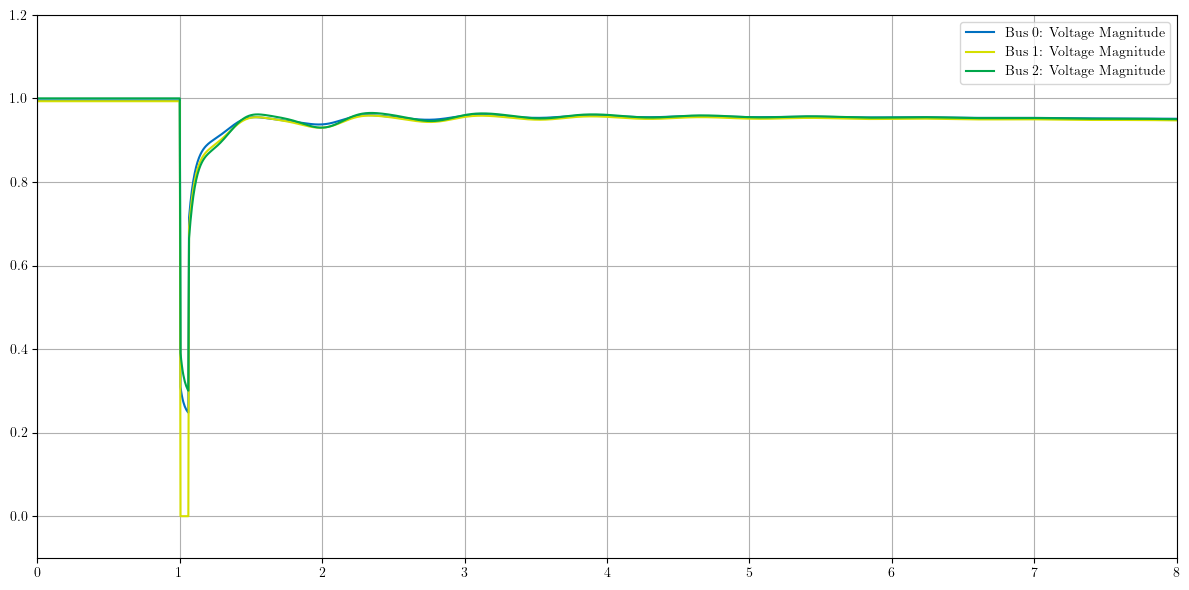

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(
    res_oltc.index.values,
    res_oltc["Bus 0: Voltage Magnitude"],
    label="Bus 0: Voltage Magnitude",
)
plt.plot(
    res_oltc.index.values,
    res_oltc["Bus 1: Voltage Magnitude"],
    label="Bus 1: Voltage Magnitude",
)
plt.plot(
    res_oltc.index.values,
    res_oltc["Bus 2: Voltage Magnitude"],
    label="Bus 2: Voltage Magnitude",
)

plt.grid()
plt.legend()

plt.xlim(xlims)
plt.ylim(ylims_v)

plt.show()

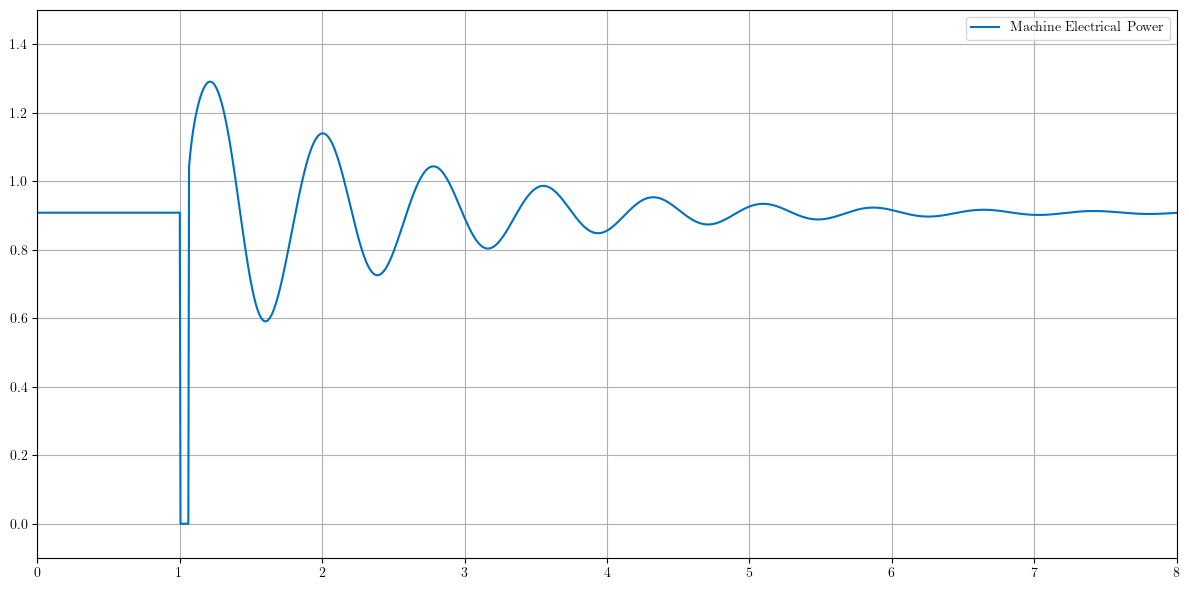

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(
    res_oltc.index.values, res_oltc["Machine P_e"], label="Machine Electrical Power"
)
# plt.plot(res_oltc.index.values, res_oltc['Machine P_m'], label='Machine Mechanical Power')

plt.xlim(xlims)
plt.ylim(ylims_p)
plt.grid()
plt.legend()

plt.show()

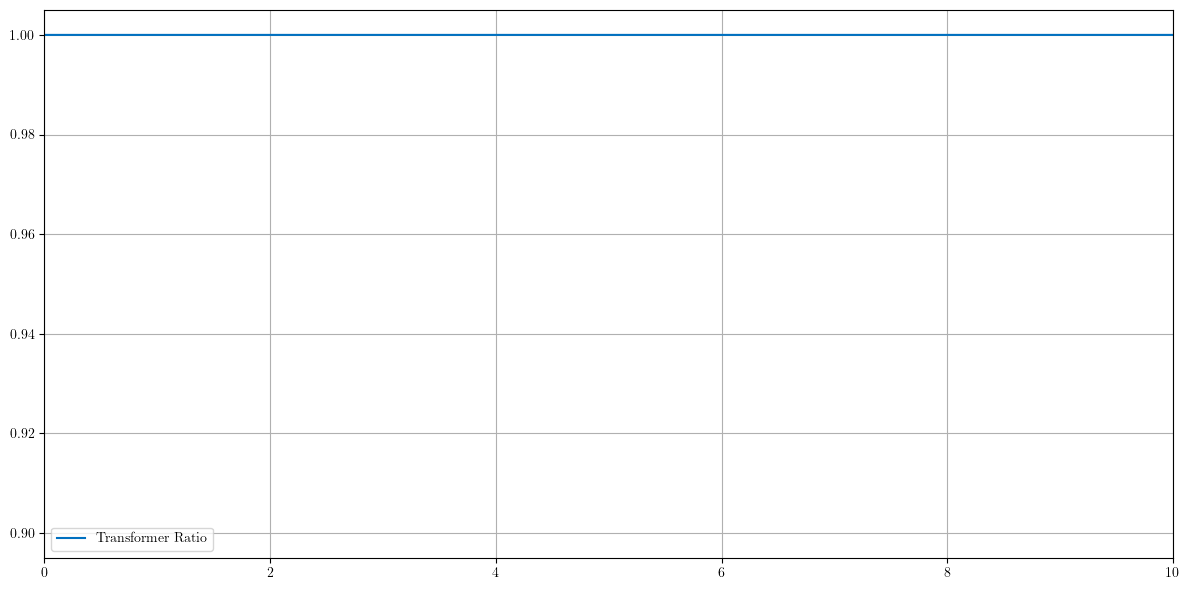

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(
    res_oltc.index.values, res_oltc["Transformer Ratio"], label="Transformer Ratio"
)

plt.xlim(0, 10)
# plt.ylim(-0.5, 1.5)
plt.grid()
plt.legend()

plt.show()

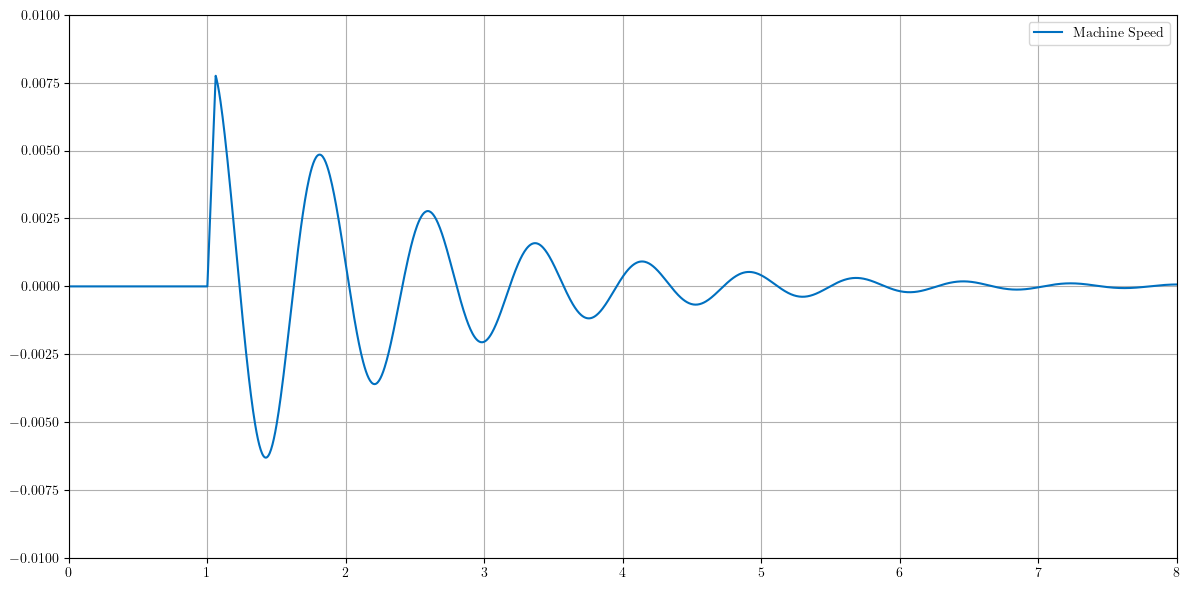

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(res_oltc.index.values, res_oltc.iloc[:, 3], label="Machine Speed")
# plt.plot(res_oltc.index.values, res_oltc.iloc[:, 4], label='Machine Angle')

plt.xlim(xlims)
plt.ylim(ylims_speed)
plt.grid()
plt.legend()

plt.show()

## FSM Controlled (Voltage Dependent Skipping)

In [17]:
sim_fsm = Pss(
    parallel_sims=parallel_sims,
    sim_time=sim_time,
    time_step=0.005,
    solver="heun",
    grid_data=ibb(
        measure_side="lv",
        trans_type="oltc",
        trans_control="fsm",
        param_dict_oltc=param_dict_fsm,
        controllers=False,
    ),
)

rec_fsm = Recorder(sim=sim_fsm, recorder_dict=record_dict_case2_oltc)
record_list_fsm = rec_fsm.record_list()

set_scenario(sim_fsm, rec_fsm)

t, recorder_fsm = sim_fsm.run()

res_fsm = pd.DataFrame(recorder_fsm[0, :, :], columns=record_list_fsm)
res_fsm["t"] = t
res_fsm.set_index("t", inplace=True)

res_fsm.head()

Load flow finished in 3 iterations with error 2.65e-09 in 0.0032 seconds


100%|██████████| 24000/24000 [00:21<00:00, 1104.46it/s]

Dynamic simulation finished in 21.74 seconds


,Bus 0: Voltage Magnitude,Bus 1: Voltage Magnitude,Bus 2: Voltage Magnitude,Machine Speed,Machine Angle,Machine P_e,Machine P_m,Transformer Ratio,Voltage Difference
t,,,,,,,,,
0.000,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,1.110223e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,0.016533+0.000000j
0.005,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,2.101494e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,0.012208+0.000000j
0.010,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,2.973812e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,0.007630+0.000000j
0.015,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,3.806479e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,0.004769+0.000000j
0.020,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,4.599495e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,0.002981+0.000000j


### Inspection of Results

/Users/maxikoehler/Documents/GitHub/diffpssi_b/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/maxikoehler/Documents/GitHub/diffpssi_b/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


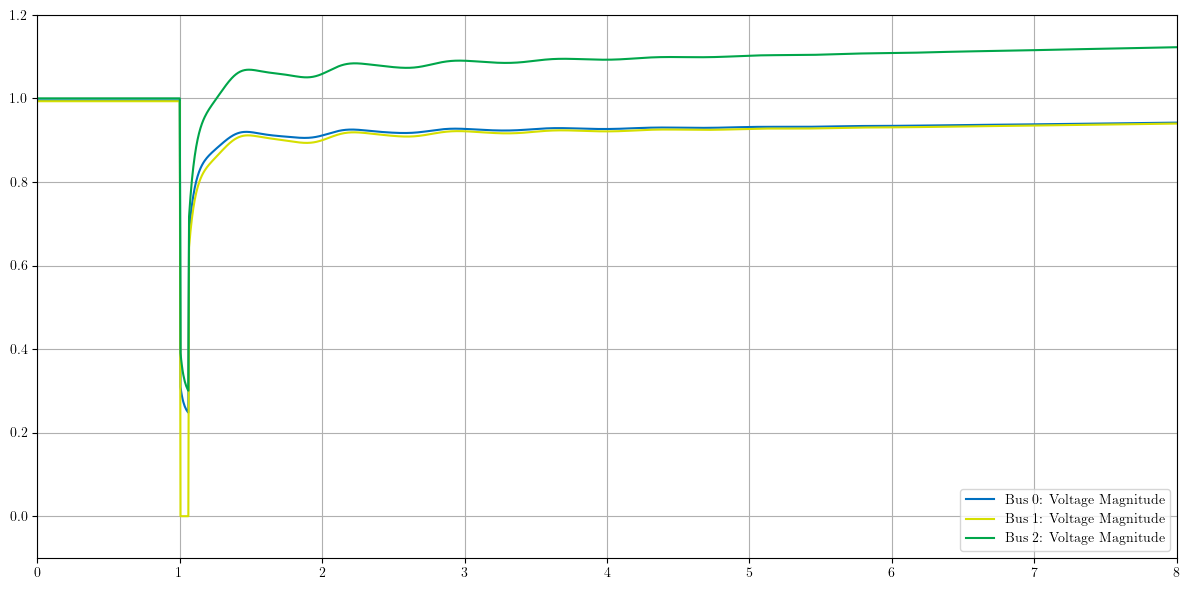

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(
    res_fsm.index.values,
    res_fsm["Bus 0: Voltage Magnitude"],
    label="Bus 0: Voltage Magnitude",
)
plt.plot(
    res_fsm.index.values,
    res_fsm["Bus 1: Voltage Magnitude"],
    label="Bus 1: Voltage Magnitude",
)
plt.plot(
    res_fsm.index.values,
    res_fsm["Bus 2: Voltage Magnitude"],
    label="Bus 2: Voltage Magnitude",
)

plt.grid()
plt.legend()

plt.xlim(xlims)
plt.ylim(ylims_v)

plt.show()

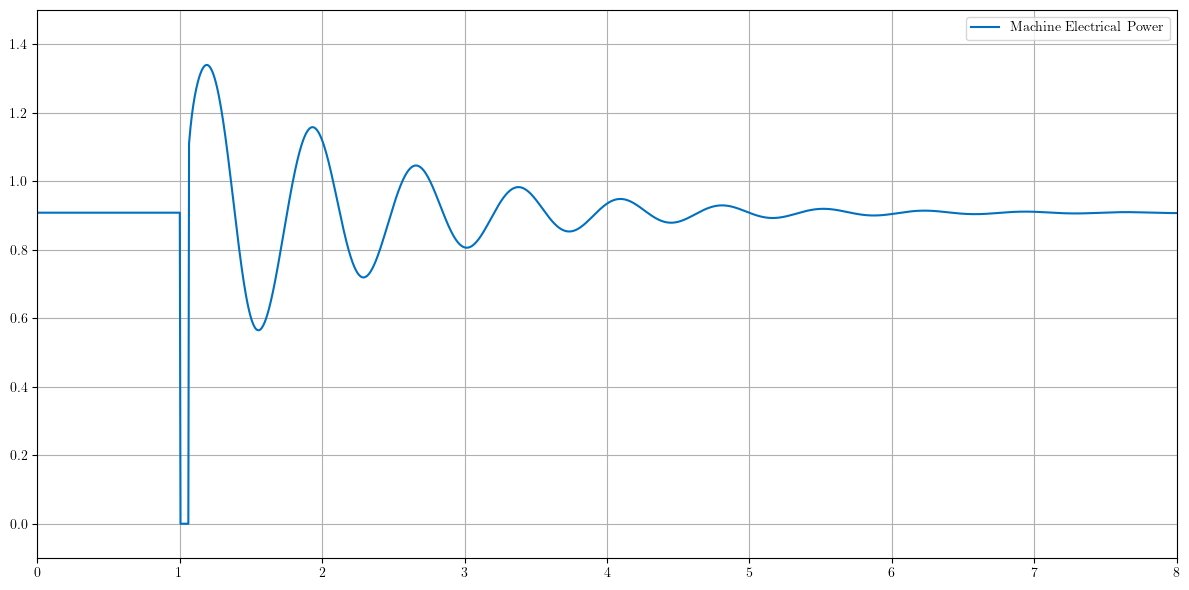

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(res_fsm.index.values, res_fsm["Machine P_e"], label="Machine Electrical Power")
# plt.plot(res_fsm.index.values, res_fsm['Machine P_m'], label='Machine Mechanical Power')

plt.xlim(xlims)
plt.ylim(ylims_p)
plt.grid()
plt.legend()

plt.show()

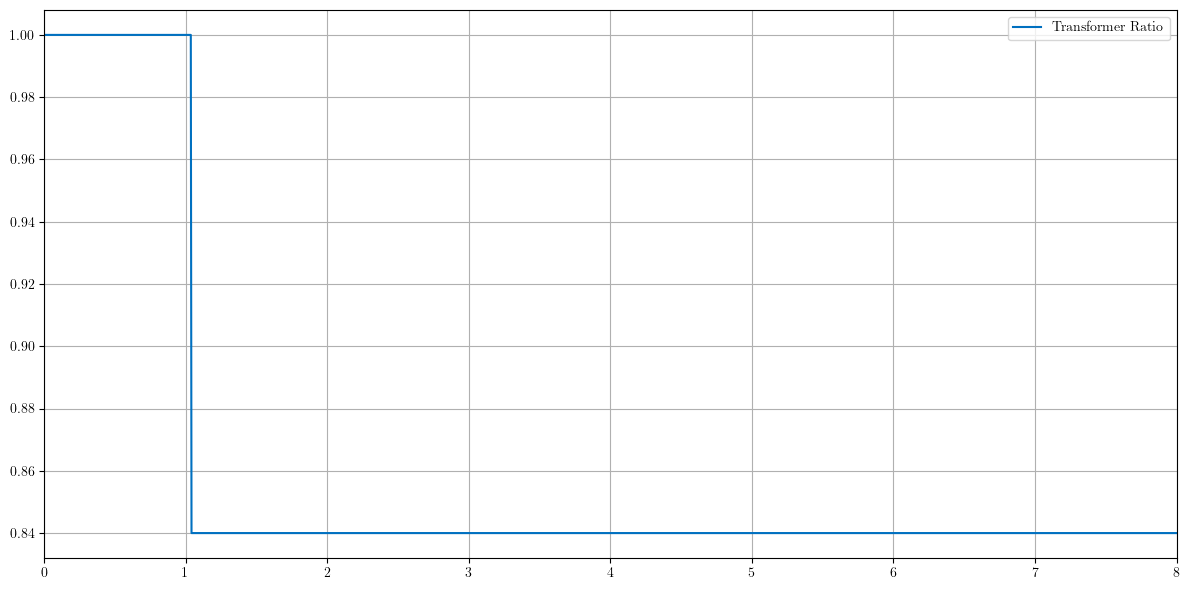

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(res_fsm.index.values, res_fsm["Transformer Ratio"], label="Transformer Ratio")

plt.xlim(xlims)
# plt.ylim(-0.5, 1.5)
plt.grid()
plt.legend()

plt.show()

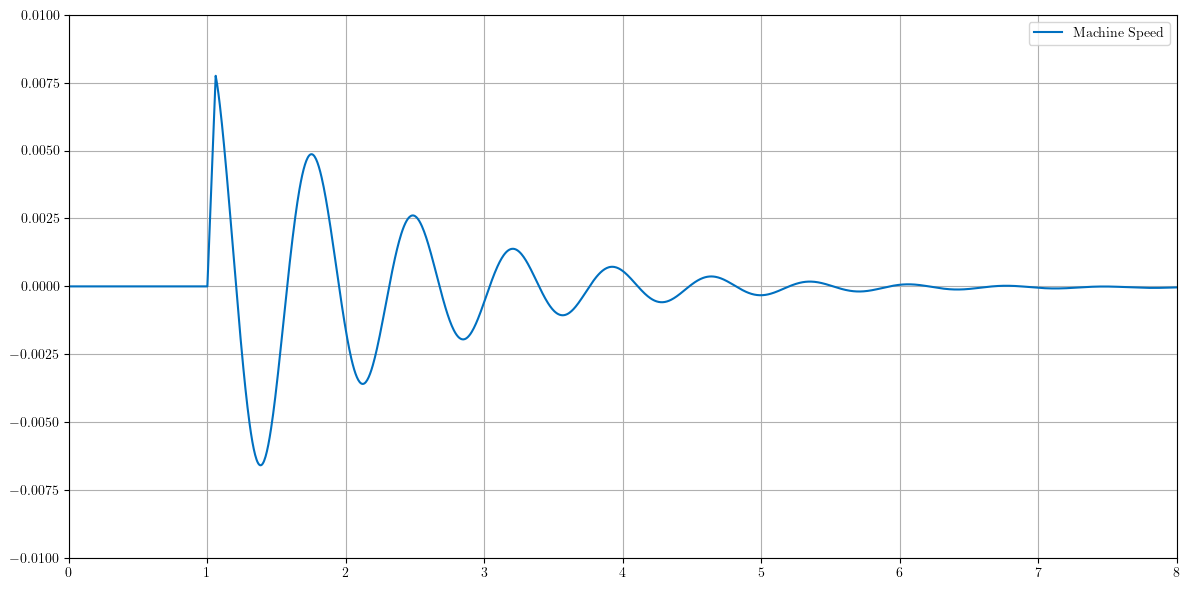

In [21]:
plt.figure(figsize=(12, 6))

plt.plot(res_fsm.index.values, res_fsm.iloc[:, 3], label="Machine Speed")
# plt.plot(res_fsm.index.values, res_fsm.iloc[:, 4], label='Machine Angle')

plt.xlim(xlims)
plt.ylim(ylims_speed)
plt.grid()
plt.legend()

plt.show()

## FSM Controlled (FSM Prefered)

In [22]:
sim_fsm_2 = Pss(
    parallel_sims=parallel_sims,
    sim_time=sim_time,
    time_step=0.005,
    solver="heun",
    grid_data=ibb(
        measure_side="lv",
        trans_type="oltc",
        trans_control="fsm_2",
        param_dict_oltc=param_dict_fsm,
        controllers=False,
    ),
)

rec_fsm_2 = Recorder(sim=sim_fsm_2, recorder_dict=record_dict_case2_oltc)
record_list_fsm_2 = rec_fsm_2.record_list()

set_scenario(sim_fsm_2, rec_fsm_2)

t, recorder_fsm_2 = sim_fsm_2.run()

res_fsm_2 = pd.DataFrame(recorder_fsm_2[0, :, :], columns=record_list_fsm_2)
res_fsm_2["t"] = t
res_fsm_2.set_index("t", inplace=True)

res_fsm_2.head()

Load flow finished in 3 iterations with error 2.65e-09 in 0.0030 seconds


100%|██████████| 24000/24000 [00:21<00:00, 1099.47it/s]


Dynamic simulation finished in 21.84 seconds


,Bus 0: Voltage Magnitude,Bus 1: Voltage Magnitude,Bus 2: Voltage Magnitude,Machine Speed,Machine Angle,Machine P_e,Machine P_m,Transformer Ratio,Voltage Difference
t,,,,,,,,,
0.000,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,1.110223e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,0.016533+0.000000j
0.005,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,2.101494e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,0.012208+0.000000j
0.010,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,2.973812e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,0.007630+0.000000j
0.015,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,3.806479e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,0.004769+0.000000j
0.020,0.995+0.000j,0.993169+0.000000j,1.0+0.0j,4.599495e-18+0.000000e+ 00j,1.112806+0.000000j,0.908182+0.000000j,0.908182+0.000000j,1.0+0.0j,0.002981+0.000000j


### Inspection of the Results

/Users/maxikoehler/Documents/GitHub/diffpssi_b/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/maxikoehler/Documents/GitHub/diffpssi_b/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


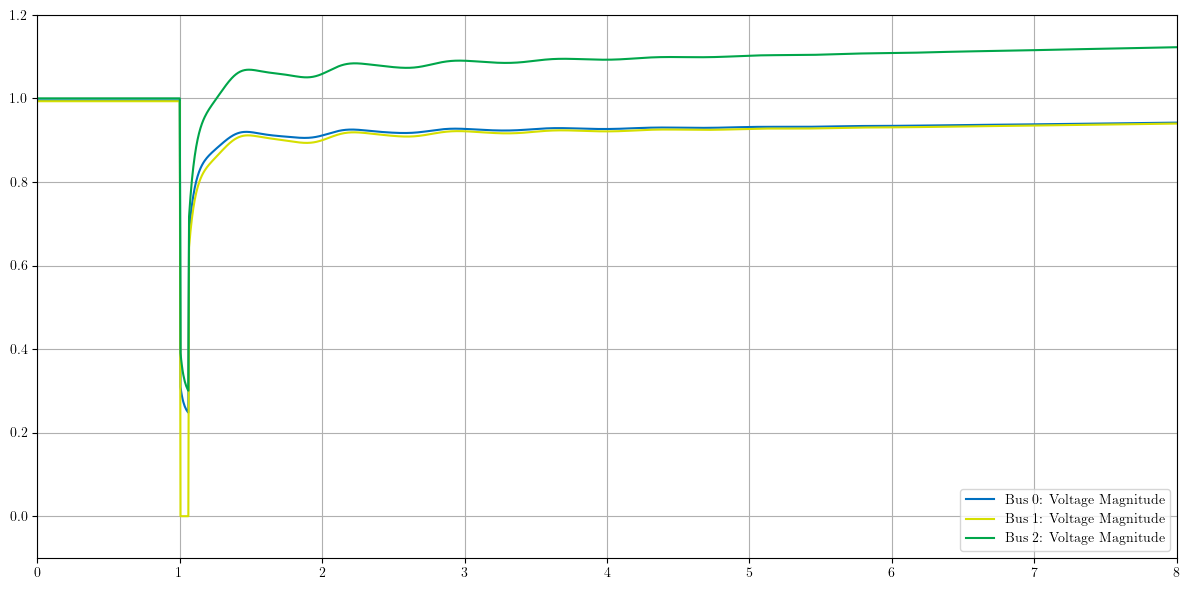

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(
    res_fsm_2.index.values,
    res_fsm_2["Bus 0: Voltage Magnitude"],
    label="Bus 0: Voltage Magnitude",
)
plt.plot(
    res_fsm_2.index.values,
    res_fsm_2["Bus 1: Voltage Magnitude"],
    label="Bus 1: Voltage Magnitude",
)
plt.plot(
    res_fsm_2.index.values,
    res_fsm_2["Bus 2: Voltage Magnitude"],
    label="Bus 2: Voltage Magnitude",
)

plt.grid()
plt.legend()

plt.xlim(xlims)
plt.ylim(ylims_v)

plt.show()

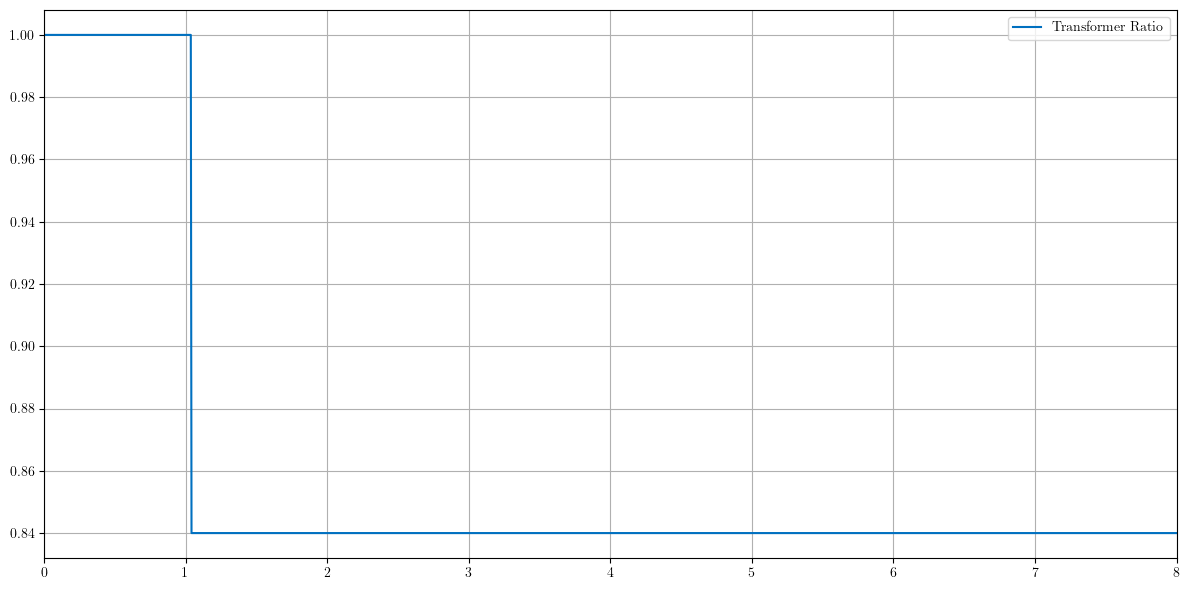

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    res_fsm_2.index.values, res_fsm_2["Transformer Ratio"], label="Transformer Ratio"
)
# plt.plot(res_fsm_2.index.values, res_fsm_2['Machine P_m'], label='Machine Mechanical Power')

plt.xlim(xlims)
# plt.ylim(-0.5, 1.5)
plt.grid()
plt.legend()

plt.show()

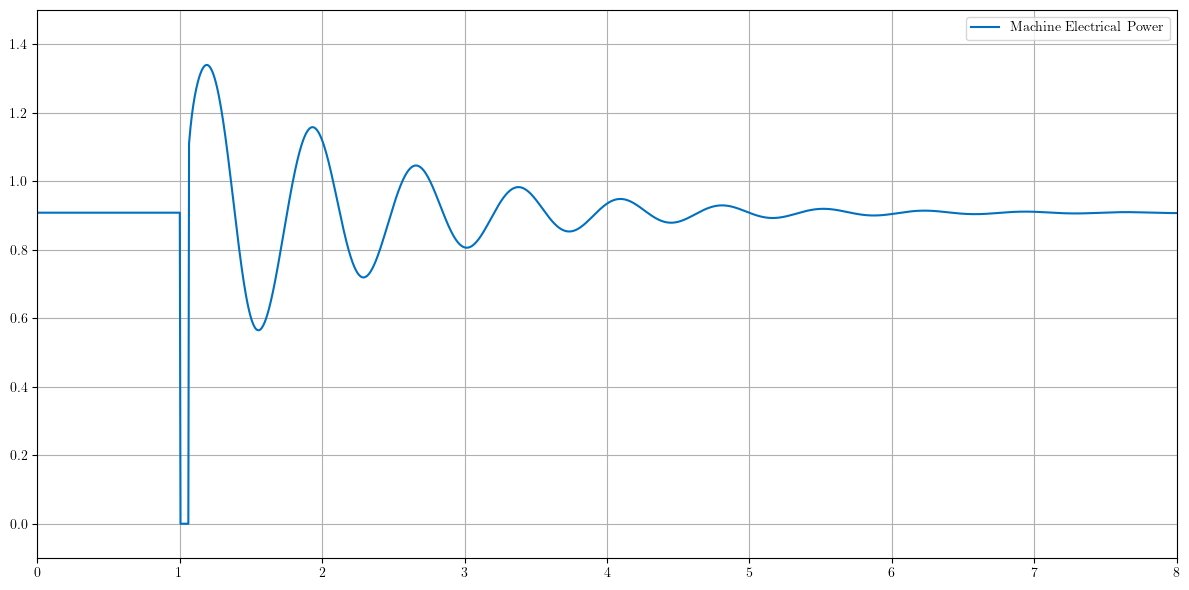

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(
    res_fsm_2.index.values, res_fsm_2["Machine P_e"], label="Machine Electrical Power"
)
# plt.plot(res_fsm_2.index.values, res_fsm_2['Machine P_m'], label='Machine Mechanical Power')

plt.xlim(xlims)
plt.ylim(ylims_p)
plt.grid()
plt.legend()

plt.show()

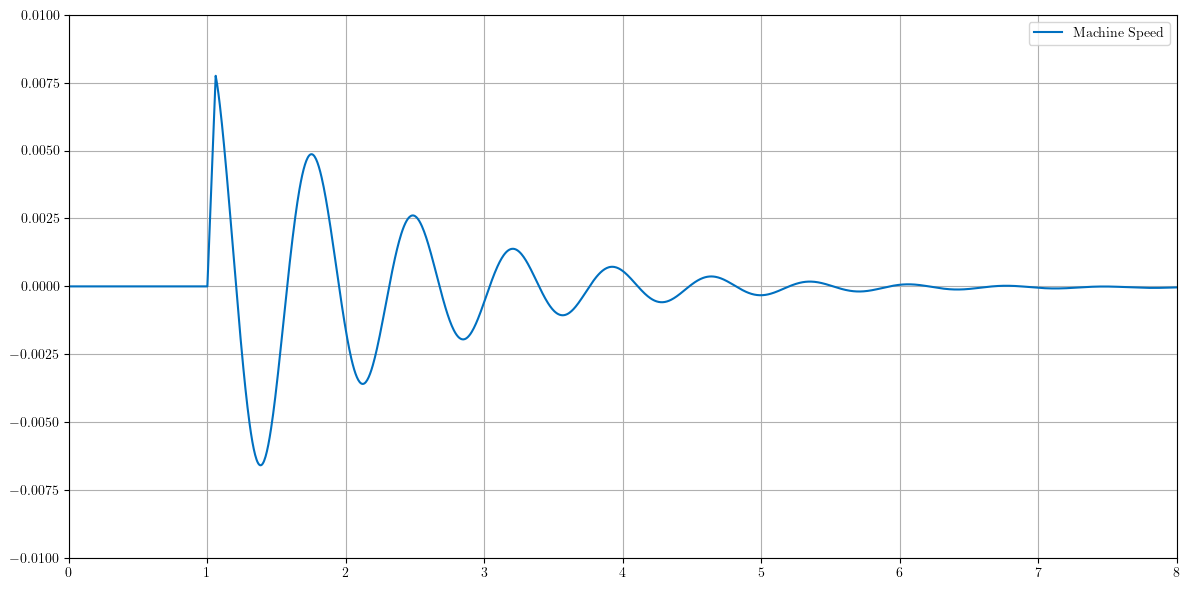

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(res_fsm_2.index.values, res_fsm_2.iloc[:, 3], label="Machine Speed")
# plt.plot(res_fsm_2.index.values, res_fsm_2.iloc[:, 4], label='Machine Angle')

plt.xlim(xlims)
plt.ylim(ylims_speed)
plt.grid()
plt.legend()

plt.show()

## Comparative Plots

This section compares the results from all simulations, resp. control schemes.

### Bus Voltages

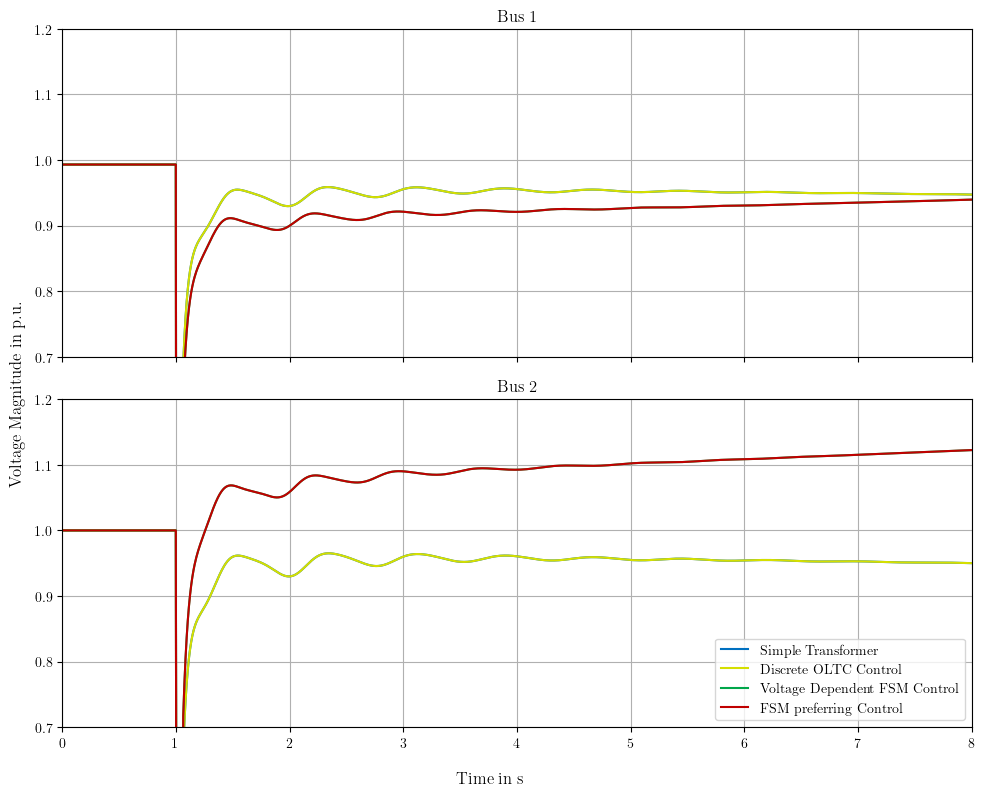

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(
    res_fsm_2.index.values,
    res_simple["Bus 1: Voltage Magnitude"],
    label="Simple Transformer",
)
ax[1].plot(
    res_fsm_2.index.values,
    res_simple["Bus 2: Voltage Magnitude"],
    label="Simple Transformer",
)

ax[0].plot(
    res_fsm_2.index.values,
    res_oltc["Bus 1: Voltage Magnitude"],
    label="Discrete OLTC Control",
)
ax[1].plot(
    res_fsm_2.index.values,
    res_oltc["Bus 2: Voltage Magnitude"],
    label="Discrete OLTC Control",
)

ax[0].plot(
    res_fsm_2.index.values,
    res_fsm["Bus 1: Voltage Magnitude"],
    label="Voltage Dependent FSM Control",
)
ax[1].plot(
    res_fsm_2.index.values,
    res_fsm["Bus 2: Voltage Magnitude"],
    label="Voltage Dependent FSM Control",
)

ax[0].plot(
    res_fsm_2.index.values,
    res_fsm_2["Bus 1: Voltage Magnitude"],
    label="FSM preferring Control",
)
ax[1].plot(
    res_fsm_2.index.values,
    res_fsm_2["Bus 2: Voltage Magnitude"],
    label="FSM preferring Control",
)

for i in range(2):
    ax[i].set_xlim(xlims)
    ax[i].set_ylim(0.7, 1.2)
    ax[i].set_title(f"Bus {i+1}")
    ax[i].grid()

# ax[1].legend(loc='right', bbox_to_anchor=(1, 1))
ax[1].legend(loc="best")

fig.supxlabel("Time in s")
fig.supylabel("Voltage Magnitude in p.u.")

plt.savefig(save + "case2_tds_voltages_zoomed.pdf")

plt.tight_layout()
plt.show()

### Transformer Parameters

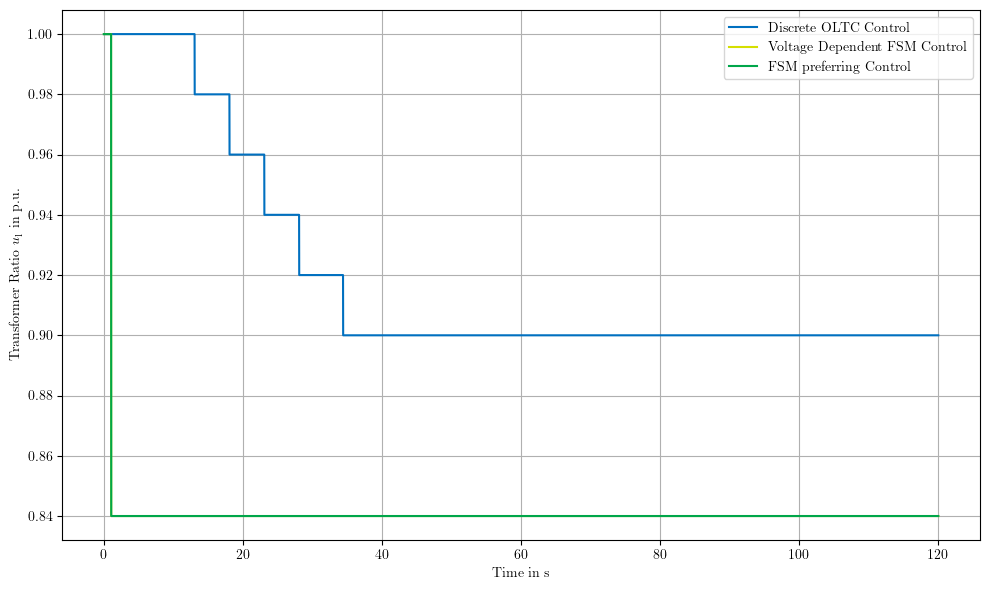

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    res_fsm_2.index.values, res_oltc["Transformer Ratio"], label="Discrete OLTC Control"
)
plt.plot(
    res_fsm_2.index.values,
    res_fsm["Transformer Ratio"],
    label="Voltage Dependent FSM Control",
)
plt.plot(
    res_fsm_2.index.values,
    res_fsm_2["Transformer Ratio"],
    label="FSM preferring Control",
)

# plt.xlim(xlims)
plt.grid()
plt.legend()

plt.xlabel("Time in s")
plt.ylabel(r"Transformer Ratio $u_\mathrm{l}$ in p.u.")

# plt.title('Transformer Ratios')

plt.savefig(save + "case1_transformer_ratio.pdf")

plt.show()

### Machine Parameters

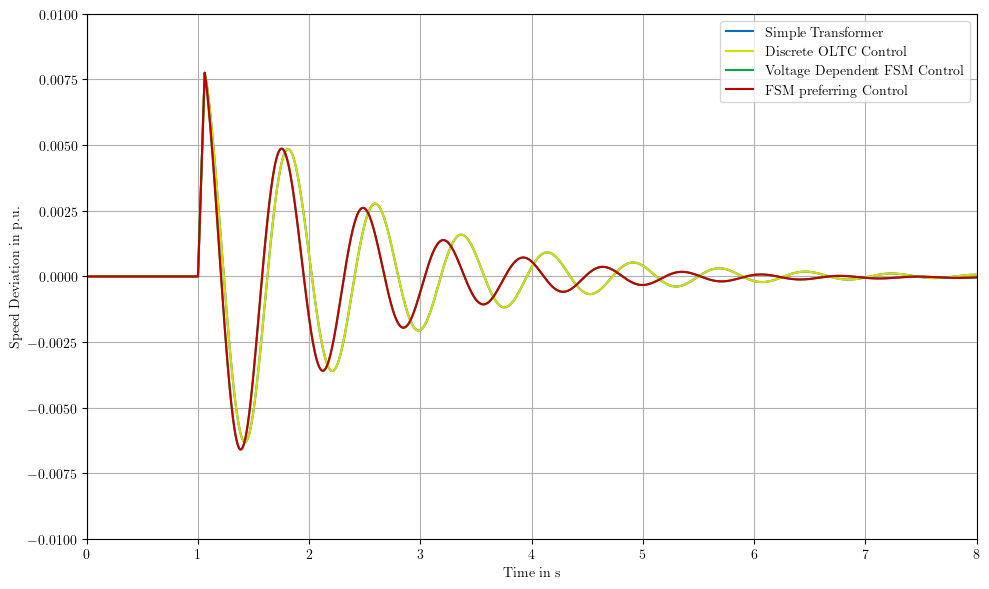

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(res_fsm_2.index.values, res_simple.iloc[:, 3], label="Simple Transformer")
plt.plot(res_fsm_2.index.values, res_oltc.iloc[:, 3], label="Discrete OLTC Control")
plt.plot(
    res_fsm_2.index.values, res_fsm.iloc[:, 3], label="Voltage Dependent FSM Control"
)
plt.plot(res_fsm_2.index.values, res_fsm_2.iloc[:, 3], label="FSM preferring Control")

plt.xlim(xlims)
plt.ylim(ylims_speed)
plt.grid()
plt.legend()

plt.ylabel("Speed Deviation in p.u.")
plt.xlabel("Time in s")

# plt.title('Machine speed for the generator at bus 2')

plt.savefig(save + "case2_machine_speed.pdf")

plt.show()

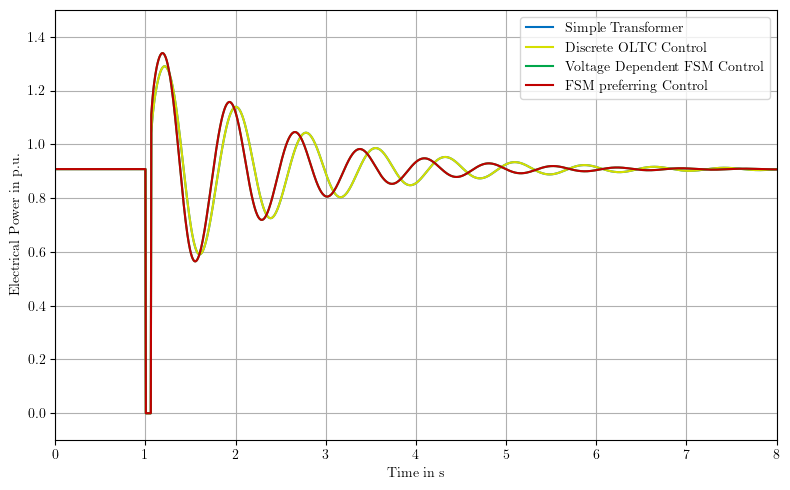

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(res_fsm_2.index.values, res_simple["Machine P_e"], label="Simple Transformer")
plt.plot(res_fsm_2.index.values, res_oltc["Machine P_e"], label="Discrete OLTC Control")
plt.plot(
    res_fsm_2.index.values,
    res_fsm["Machine P_e"],
    label="Voltage Dependent FSM Control",
)
plt.plot(
    res_fsm_2.index.values, res_fsm_2["Machine P_e"], label="FSM preferring Control"
)

plt.xlim(xlims)
plt.ylim(ylims_p)
plt.grid()
plt.legend()

plt.ylabel("Electrical Power in p.u.")
plt.xlabel("Time in s")
# plt.title('Electrical power for the generator at bus 2')

plt.savefig(save + "case2_power_electrical.pdf")

plt.show()

## TVI Envelopes

### Bus Voltages and Integral Values

In [31]:
violation = ViolationIntegral(envelope="TVI")
violation.set_env_params(
    env_params={
        "beta": 0.1,
        "v_st": 0.9,
        "t_start": fault_end,
    }
)

env = violation.get_env(t)

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(res_fsm_2.index.values, env[0], linestyle="dashed", color=ees_black)
plt.plot(res_fsm_2.index.values, env[1], linestyle="dashed", color=ees_black)

plt.plot(
    res_fsm_2.index.values,
    res_simple["Bus 0: Voltage Magnitude"],
    label="Simple Transformer",
)
plt.plot(
    res_fsm_2.index.values,
    res_oltc["Bus 0: Voltage Magnitude"],
    label="Discrete OLTC Control",
)
plt.plot(
    res_fsm_2.index.values,
    res_fsm["Bus 0: Voltage Magnitude"],
    label="Voltage Dependent FSM Control",
)
plt.plot(
    res_fsm_2.index.values,
    res_fsm_2["Bus 0: Voltage Magnitude"],
    label="FSM preferring Control",
)

plt.ylim(0, 2)
plt.title(f"Bus 0")
plt.grid()

plt.legend() #loc="upper right", bbox_to_anchor=(1, 1.2))

plt.xlabel("Time in s")
plt.ylabel("Voltage Magnitude in p.u.")

plt.savefig(save + "case1_tds_bus_voltages.pdf")

plt.show()

NameError: name 'ees_black' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
violation_integrals = {
    "simple": [],
    "oltc": [],
    "fsm": [],
    "fsm_2": [],
}

csi = {
    "simple": None,
    "oltc": None,
    "fsm": None,
    "fsm_2": None,
}


for i in range(1, 4):
    violation_integrals["simple"].append(
        violation.get_result(time=t, v_bb=res_simple.iloc[:, i].values)
    )
    violation_integrals["oltc"].append(
        violation.get_result(time=t, v_bb=res_oltc.iloc[:, i].values)
    )
    violation_integrals["fsm"].append(
        violation.get_result(time=t, v_bb=res_fsm.iloc[:, i].values)
    )
    violation_integrals["fsm_2"].append(
        violation.get_result(time=t, v_bb=res_fsm_2.iloc[:, i].values)
    )

for key in violation_integrals.keys():
    print(f"{key}: ", np.round(np.abs(violation_integrals[key]), 2))
    csi[key] = 1 / 3 * np.sum(np.abs(violation_integrals[key]))
    print(f"{key}: ", np.round(csi[key], 2))

### Time Stamps of the Violations

In [ ]:
crit_times = CrtiticalTimes()
crit_times.tvi_time = env  # add_env_data(time=t)

simple_env_cuts = []
oltc_env_cuts = []
fsm_env_cuts = []
fsm_2_env_cuts = []

for i in range(3):
    simple_env_cuts.append(
        crit_times.get_result(t, res_simple.iloc[:, 0:3].values)[f"bus_{i}"]["tvi"][-1]
    )
    oltc_env_cuts.append(
        crit_times.get_result(t, res_oltc.iloc[:, 0:3].values)[f"bus_{i}"]["tvi"][-1]
    )
    fsm_env_cuts.append(
        crit_times.get_result(t, res_fsm.iloc[:, 0:3].values)[f"bus_{i}"]["tvi"][-1]
    )
    fsm_2_env_cuts.append(
        crit_times.get_result(t, res_fsm_2.iloc[:, 0:3].values)[f"bus_{i}"]["tvi"][-1]
    )

print(simple_env_cuts)
print(oltc_env_cuts)
print(fsm_env_cuts)
print(fsm_2_env_cuts)